In [1]:
import pandas as pd
import sys

sys.path.append("../")

import bayesflow as bf

from dmc import dmc_helpers


2026-03-25 08:28:29.974296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774423709.986490   49529 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774423709.990130   49529 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774423709.999157   49529 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774423709.999175   49529 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774423709.999176   49529 computation_placer.cc:177] computation placer alr

# Read data sets

In [2]:
narrow_data = pd.read_csv('../empirical_data/experiment_data_narrow.csv')

In [3]:
wide_data = pd.read_csv('../empirical_data/experiment_data_wide.csv')

In [4]:
narrow_data

,Unnamed: 0,participant,rt,accuracy,congruency_num,spacing_num
0,0,6361,0.4690,1,0,1
1,1,5281,0.4540,1,0,1
2,2,8785,0.4345,1,0,1
3,3,6253,0.2900,1,1,1
4,4,6427,0.5150,1,0,1
...,...,...,...,...,...,...
24842,25479,1601,0.5150,1,1,1
24843,25480,1813,0.4891,1,1,1
24844,25481,8311,0.4300,1,0,1
24845,25482,161753,0.4920,1,1,1


## Recode congruency 

In [5]:
narrow_data['congruency'] = narrow_data['congruency_num'].replace({0: 'congruent', 1:'incongruent'})

wide_data['congruency'] = wide_data['congruency_num'].replace({0: 'congruent', 1:'incongruent'})

## Narrow Spacing - Compute Stats (CDF, CAF, Delta)

In [6]:
caf, cdf, delta = dmc_helpers.compute_stats(narrow_data, id_name='participant', congruency='congruency')

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: title={'center': 'CAF'}, xlabel='Bins', ylabel='CAF'>,
        <Axes: title={'center': 'CDF'}, xlabel='RT[s]', ylabel='Cumulative Density'>,
        <Axes: title={'center': '$\\Delta$-Function'}, xlabel='RT[s]', ylabel='$\\Delta$'>],
       dtype=object))

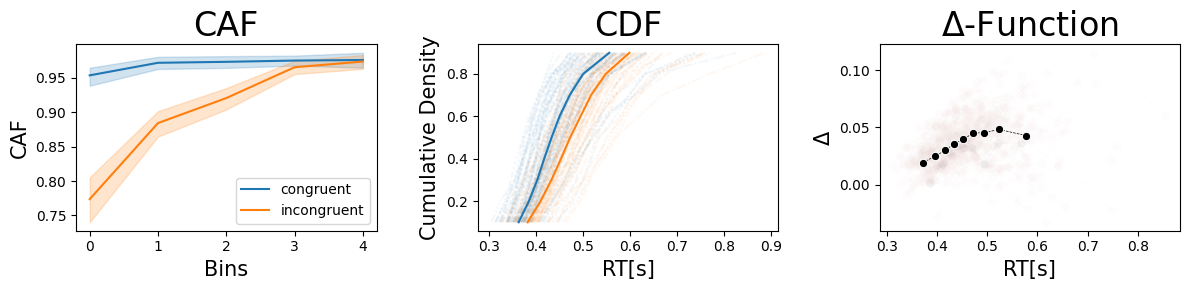

In [7]:
dmc_helpers.plot_stats(caf, cdf, delta, id_name='participant', congruency='congruency')

## Wide Spacing - Compute Stats (CDF, CAF, Delta)

In [9]:
caf, cdf, delta = dmc_helpers.compute_stats(wide_data, id_name='participant', congruency='congruency')

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: title={'center': 'CAF'}, xlabel='Bins', ylabel='CAF'>,
        <Axes: title={'center': 'CDF'}, xlabel='RT[s]', ylabel='Cumulative Density'>,
        <Axes: title={'center': '$\\Delta$-Function'}, xlabel='RT[s]', ylabel='$\\Delta$'>],
       dtype=object))

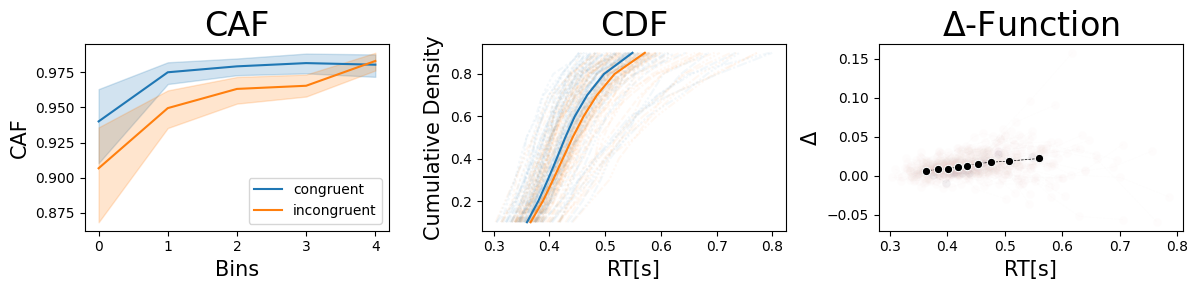

In [10]:
dmc_helpers.plot_stats(caf, cdf, delta, id_name='participant', congruency='congruency')